# EDA: MIMIC-IV-Ext-BHC Dataset

**Paper**: *A dataset and benchmark for hospital course summarization with adapted large language models* (Aali et al., 2024, JAMIA)

**Source**: PhysioNet — MIMIC-IV-Ext-BHC v1.2.0

**Contents**: 270,033 preprocessed clinical note ↔ BHC summary pairs from MIMIC-IV-Note

---

### Mapping to Thesis Variables
| Thesis Variable | CSV Column | Description |
|---|---|---|
| **C** (Context) | `input` | Preprocessed discharge note (excl. BHC), avg 2267 tokens |
| **L** (Labeled Summary) | `target` | BHC written by physician, avg 564 tokens |
| `input_tokens` | Token count (GPT-4 tokenizer) for input |
| `target_tokens` | Token count (GPT-4 tokenizer) for target |

### Goals
1. Load & validate schema
2. Distribution of input/target lengths
3. Identify context length ranges (0-1K, 1K-2K, 2K-4K)
4. Sample records for qualitative inspection
5. Assess suitability for baseline experiment

### ⚠️ Key Warning from Note
Doctor-written BHC summaries (L) contain ~30% hallucinations and ~35% omissions (Fig 5b of paper). For Golden Dataset, these must be manually cleaned.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_colwidth', 200)

CSV_PATH = '../../data/raw/mimic-iv-ext-bhc-labeled-clinical-notes-dataset-for-hospital-course-summarization-1.2.0/mimic-iv-bhc.csv'
print('Loading dataset (2.7GB, may take a minute)...')

Loading dataset (2.7GB, may take a minute)...


## 1. Load & Basic Stats

In [3]:
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
df.head(3)

Shape: (270033, 5)
Columns: ['note_id', 'input', 'target', 'input_tokens', 'target_tokens']
Memory usage: 2.77 GB


,note_id,input,target,input_tokens,target_tokens
0,10000032-DS-21,<SEX> F <SERVICE> MEDICINE <ALLERGIES> No Known Allergies / Adverse Drug Reactions <ATTENDING> ___ <CHIEF COMPLAINT> Worsening ABD distension and pain <MAJOR SURGICAL OR INVASIVE PROCEDURE> Parace...,"___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, bioplar, PTSD, presented from OSH ED with worsening abd distension over past week and confusion. # Ascites - p/w worsening abd distension...",1946,231
1,10000032-DS-22,<SEX> F <SERVICE> MEDICINE <ALLERGIES> Percocet <ATTENDING> ___. <CHIEF COMPLAINT> abdominal fullness and discomfort <MAJOR SURGICAL OR INVASIVE PROCEDURE> ___ diagnostic paracentesis ___ therapeu...,"___ with HIV on HAART, HCV cirrhosis with ascites and HE, h/o IVDU, COPD, bipolar disorder presents with abdominal discomfort due to ___ ascites. # ASCITES. Now diuretic refractory given last tap ...",2183,810
2,10000117-DS-21,<SEX> F <SERVICE> MEDICINE <ALLERGIES> omeprazole <ATTENDING> ___. <CHIEF COMPLAINT> dysphagia <MAJOR SURGICAL OR INVASIVE PROCEDURE> Upper endoscopy ___ <HISTORY OF PRESENT ILLNESS> ___ w/ anxiet...,Ms. ___ is a ___ with history of GERD who presents with subacute worsening of dysphagia and foreign body sensation. This had worsened to the point where she placed herself on a pureed diet for the...,1060,172


In [4]:
# Schema validation
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Null Counts ===')
print(df.isnull().sum())
print(f'\n=== Duplicated note_ids: {df["note_id"].duplicated().sum()}')

=== Data Types ===
note_id          object
input            object
target           object
input_tokens      int64
target_tokens     int64
dtype: object

=== Null Counts ===
note_id          0
input            0
target           0
input_tokens     0
target_tokens    0
dtype: int64

=== Duplicated note_ids: 0


In [5]:
# Basic statistics of token counts
print('=== Input Token Stats ===')
print(df['input_tokens'].describe())
print(f'\n=== Target Token Stats ===')
print(df['target_tokens'].describe())
print(f'\n=== Compression Ratio (input/target) ===')
df['compression_ratio'] = df['input_tokens'] / df['target_tokens']
print(df['compression_ratio'].describe())

=== Input Token Stats ===
count    270033.000000
mean       2266.714946
std         914.394199
min          67.000000
25%        1632.000000
50%        2166.000000
75%        2770.000000
max       13552.000000
Name: input_tokens, dtype: float64

=== Target Token Stats ===
count    270033.000000
mean        563.964512
std         409.756030
min           1.000000
25%         279.000000
50%         453.000000
75%         734.000000
max        6341.000000
Name: target_tokens, dtype: float64

=== Compression Ratio (input/target) ===
count    270033.000000
mean          5.774285
std          14.163270
min           0.112797
25%           3.268222
50%           4.649038
75%           6.754889
max        3079.000000
Name: compression_ratio, dtype: float64


## 2. Token Length Distributions

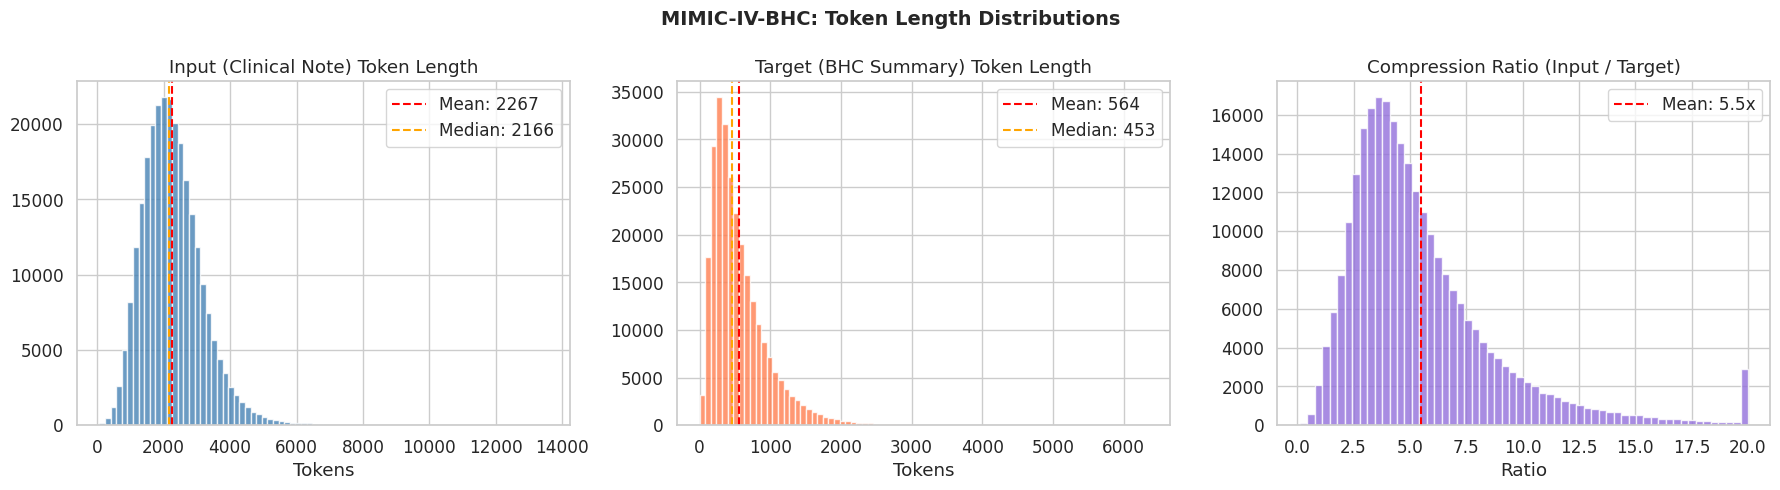

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Input tokens
axes[0].hist(df['input_tokens'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['input_tokens'].mean(), color='red', linestyle='--', label=f'Mean: {df["input_tokens"].mean():.0f}')
axes[0].axvline(df['input_tokens'].median(), color='orange', linestyle='--', label=f'Median: {df["input_tokens"].median():.0f}')
axes[0].set_title('Input (Clinical Note) Token Length')
axes[0].set_xlabel('Tokens')
axes[0].legend()

# Target tokens
axes[1].hist(df['target_tokens'], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(df['target_tokens'].mean(), color='red', linestyle='--', label=f'Mean: {df["target_tokens"].mean():.0f}')
axes[1].axvline(df['target_tokens'].median(), color='orange', linestyle='--', label=f'Median: {df["target_tokens"].median():.0f}')
axes[1].set_title('Target (BHC Summary) Token Length')
axes[1].set_xlabel('Tokens')
axes[1].legend()

# Compression ratio
ratio = df['compression_ratio'].clip(upper=20)
axes[2].hist(ratio, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[2].axvline(ratio.mean(), color='red', linestyle='--', label=f'Mean: {ratio.mean():.1f}x')
axes[2].set_title('Compression Ratio (Input / Target)')
axes[2].set_xlabel('Ratio')
axes[2].legend()

plt.suptitle('MIMIC-IV-BHC: Token Length Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Context Length Ranges (Paper's Test Splits)

In [7]:
# Paper defines 3 ranges for testing
bins = [0, 1024, 2048, 4096, float('inf')]
labels = ['0-1K', '1K-2K', '2K-4K', '4K+']
df['context_range'] = pd.cut(df['input_tokens'], bins=bins, labels=labels, right=True)

range_stats = df.groupby('context_range', observed=True).agg(
    count=('note_id', 'count'),
    input_mean=('input_tokens', 'mean'),
    input_std=('input_tokens', 'std'),
    target_mean=('target_tokens', 'mean'),
    target_std=('target_tokens', 'std'),
).round(0)
range_stats['pct'] = (range_stats['count'] / len(df) * 100).round(1)
print('=== Records by Context Length Range ===')
range_stats

=== Records by Context Length Range ===


,count,input_mean,input_std,target_mean,target_std,pct
context_range,,,,,,
0-1K,14557,799.0,187.0,278.0,220.0,5.4
1K-2K,105187,1603.0,281.0,385.0,275.0,39.0
2K-4K,140769,2737.0,499.0,682.0,397.0,52.1
4K+,9520,4885.0,899.0,1230.0,627.0,3.5


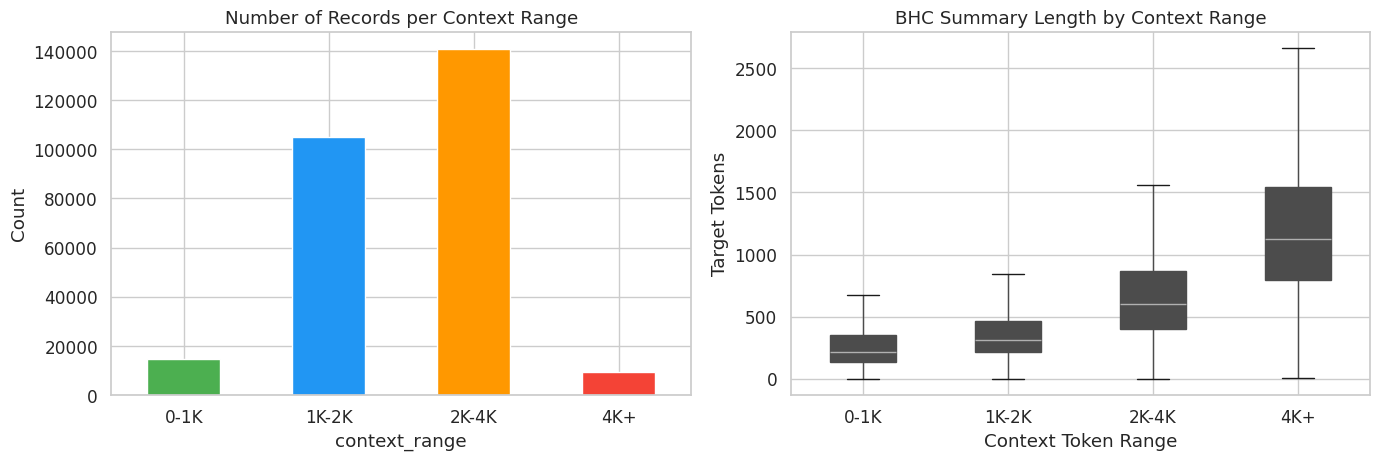

In [8]:
# Visualize range distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of counts
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
range_stats['count'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Number of Records per Context Range')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Box plot of target lengths per range
df.boxplot(column='target_tokens', by='context_range', ax=axes[1],
           showfliers=False, patch_artist=True)
axes[1].set_title('BHC Summary Length by Context Range')
axes[1].set_xlabel('Context Token Range')
axes[1].set_ylabel('Target Tokens')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. Qualitative Inspection: Sample Records

In [9]:
# Sample a short record for readability
sample_short = df[df['context_range'] == '0-1K'].sample(1, random_state=42).iloc[0]

print('=' * 80)
print(f'NOTE ID: {sample_short["note_id"]}  |  Input: {sample_short["input_tokens"]} tokens  |  Target: {sample_short["target_tokens"]} tokens')
print('=' * 80)
print('\n--- CLINICAL NOTE (C) ---')
print(sample_short['input'][:2000])
print('\n--- BHC SUMMARY (L) ---')
print(sample_short['target'][:1000])

NOTE ID: 14467911-DS-5  |  Input: 682 tokens  |  Target: 144 tokens

--- CLINICAL NOTE (C) ---
<SEX> F <SERVICE> SURGERY <ALLERGIES> Compazine / Morphine Sulfate <ATTENDING> ___. <CHIEF COMPLAINT> nausea, dry heaves <MAJOR SURGICAL OR INVASIVE PROCEDURE> none <HISTORY OF PRESENT ILLNESS> ___ F s/p laparoscopic Nissen fundoplication in ___ at an OSH. She had symptoms of recurrence 6 months ago and is now s/p laparoscopic Toupet fundoplication ___ at an OSH. She presented here ___ with nausea and dry heaves. Denies hemoptysis, having normal bowel movements. <PAST MEDICAL HISTORY> PMH: R-ovarian cyst, GERD, hiatal hernia PSH: above, R-oophorectomy <SOCIAL HISTORY> ___ <FAMILY HISTORY> n/c <PHYSICAL EXAM> T 99.1, P 74, BP 156/87, RR 18, O2 97RA Gen- NAD, AxOx3 HEENT- PERRL, EOMI Heart- RRR Lungs- CTA b/l Abdomen- soft, tender at trochar sites, nondistended <PERTINENT RESULTS> ___ 05: 35AM BLOOD WBC-4.4 RBC-4.03* Hgb-12.1 Hct-34.3* MCV-85 MCH-30.1 MCHC-35.4* RDW-13.8 Plt ___ ___ 06: 00AM BL

In [10]:
# Sample a long record (2K-4K range) — the thesis target range
sample_long = df[df['context_range'] == '2K-4K'].sample(1, random_state=42).iloc[0]

print('=' * 80)
print(f'NOTE ID: {sample_long["note_id"]}  |  Input: {sample_long["input_tokens"]} tokens  |  Target: {sample_long["target_tokens"]} tokens')
print('=' * 80)
print('\n--- CLINICAL NOTE (C) [first 3000 chars] ---')
print(sample_long['input'][:3000])
print('\n--- BHC SUMMARY (L) [first 2000 chars] ---')
print(sample_long['target'][:2000])

NOTE ID: 17396354-DS-31  |  Input: 2109 tokens  |  Target: 229 tokens

--- CLINICAL NOTE (C) [first 3000 chars] ---
<SEX> F <SERVICE> SURGERY <ALLERGIES> Sulfa (Sulfonamide Antibiotics) / Demerol / Iodine-Iodine Containing / Tape ___ / Lipitor / Zocor / Neosporin Scar Solution / Bactrim / Cipro Cystitis / Levaquin / Pravastatin / IV Dye, Iodine Containing Contrast Media <ATTENDING> ___. <CHIEF COMPLAINT> Left lower extremity graft stenosis <MAJOR SURGICAL OR INVASIVE PROCEDURE> Left lower extremity diagnostic angiography on ___ <HISTORY OF PRESENT ILLNESS> ___ yo F with ESRD on HD, DM, HTN, same day admission following elective angiography of her left lower extremity. She had recently presented to the office with complaints of intermittent numbness in her left leg. <PAST MEDICAL HISTORY> PAST MEDICAL HISTORY: -Diabetic Neuropathy and Nephropathy -Left CEA ___ -Right AV fistula -Anemia-h/o UGI bleed -CHRONIC RENAL FAILURE -stage 4; secondary Hyperparathyroidism - h/o urosepsis -SLEEP AP

## 5. Text Quality Checks

In [11]:
# Check for de-identification patterns
deid_pattern = r'\[\*\*.*?\*\*\]'  # MIMIC de-id pattern: [**...**]
df['has_deid_input'] = df['input'].str.contains(deid_pattern, regex=True, na=False)
df['has_deid_target'] = df['target'].str.contains(deid_pattern, regex=True, na=False)

print(f'Records with de-id tokens in input:  {df["has_deid_input"].sum()} ({df["has_deid_input"].mean()*100:.1f}%)')
print(f'Records with de-id tokens in target: {df["has_deid_target"].sum()} ({df["has_deid_target"].mean()*100:.1f}%)')

Records with de-id tokens in input:  3 (0.0%)
Records with de-id tokens in target: 1 (0.0%)


In [12]:
# Check for section headers in input (paper says they standardized to <SECTION>)
header_pattern = r'<[A-Z ]+>'
sample_headers = df['input'].iloc[0]

import re
headers_found = re.findall(header_pattern, sample_headers)
print(f'Section headers in first record:')
for h in headers_found:
    print(f'  {h}')

Section headers in first record:
  <SEX>
  <SERVICE>
  <ALLERGIES>
  <ATTENDING>
  <CHIEF COMPLAINT>
  <MAJOR SURGICAL OR INVASIVE PROCEDURE>
  <HISTORY OF PRESENT ILLNESS>
  <PAST MEDICAL HISTORY>
  <SOCIAL HISTORY>
  <FAMILY HISTORY>
  <PHYSICAL EXAM>
  <PERTINENT RESULTS>
  <MEDICATIONS ON ADMISSION>
  <DISCHARGE MEDICATIONS>
  <DISCHARGE DISPOSITION>
  <DISCHARGE DIAGNOSIS>
  <DISCHARGE CONDITION>
  <FOLLOWUP INSTRUCTIONS>
  <DISCHARGE INSTRUCTIONS>


In [13]:
# Character-level length (for context window estimation in chars)
df['input_chars'] = df['input'].str.len()
df['target_chars'] = df['target'].str.len()

print('=== Character Length Stats ===')
print(f'Input  — Mean: {df["input_chars"].mean():.0f}, Median: {df["input_chars"].median():.0f}, Max: {df["input_chars"].max()}')
print(f'Target — Mean: {df["target_chars"].mean():.0f}, Median: {df["target_chars"].median():.0f}, Max: {df["target_chars"].max()}')

=== Character Length Stats ===
Input  — Mean: 7643, Median: 7235, Max: 43800
Target — Mean: 2423, Median: 1976, Max: 26886


## 6. Golden Dataset Candidate Selection

Per the note: use 100 samples from the **2048-4096 token range** as Golden Dataset candidates.
These are long enough to "trap" the model into hallucinating.

In [14]:
golden_candidates = df[df['context_range'] == '2K-4K']
print(f'Total candidates in 2K-4K range: {len(golden_candidates)}')
print(f'\nToken stats for these candidates:')
print(golden_candidates[['input_tokens', 'target_tokens']].describe().round(0))

# Sample 100 for golden dataset
golden_100 = golden_candidates.sample(100, random_state=42)
print(f'\nSampled 100 golden candidates')
print(f'Input tokens: {golden_100["input_tokens"].mean():.0f} ± {golden_100["input_tokens"].std():.0f}')
print(f'Target tokens: {golden_100["target_tokens"].mean():.0f} ± {golden_100["target_tokens"].std():.0f}')

Total candidates in 2K-4K range: 140769

Token stats for these candidates:
       input_tokens  target_tokens
count      140769.0       140769.0
mean         2737.0          682.0
std           499.0          397.0
min          2049.0            1.0
25%          2325.0          402.0
50%          2639.0          599.0
75%          3064.0          865.0
max          4096.0         6082.0

Sampled 100 golden candidates
Input tokens: 2764 ± 546
Target tokens: 639 ± 288


## 7. Context Window Feasibility for vLLM + BioMistral-7B

In [ ]:
# BioMistral-7B context window: 4096 tokens (Mistral base)
# Check how many records fit within different context windows
PROMPT_OVERHEAD = 150  # tokens for instruction prompt
MAX_OUTPUT = 1024  # max tokens for generated summary

context_limits = [2048, 4096, 8192, 32768]
print('=== Records fitting within context windows ===')
print(f'(Assuming {PROMPT_OVERHEAD} token prompt overhead + {MAX_OUTPUT} max output tokens)\n')

for limit in context_limits:
    available = limit - PROMPT_OVERHEAD - MAX_OUTPUT
    fits = (df['input_tokens'] <= available).sum()
    pct = fits / len(df) * 100
    print(f'Context {limit:>6} tokens → Available for input: {available:>5} → Fits: {fits:>6} records ({pct:.1f}%)')

## Summary & Conclusions

**TODO**: Fill after running notebook

### Key Findings
1. Dataset size and schema validation
2. Token length distribution characteristics
3. Text quality (de-id tokens, section headers)
4. Context window feasibility for BioMistral-7B
5. Golden Dataset candidates identified

### Suitability for Thesis
- [ ] Columns map directly to thesis variables (C, L)
- [ ] Sufficient data for train/validation
- [ ] Context fits within model context window
- [ ] Text quality is adequate for summarization